# Micro proyecto No. 2

**Universidad de los Andes**

**Integrantes:**

* David Cortes Mantilla
* Natalia Serna Hernandez

### 1. Carga y preparacion de datos

Se carga el csv de datos y se analiza la estructura del mismo, tambien se ve un preview de los registros que tienen el dataset.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv("datos_ods.csv") 
print(df.shape)
print(df.info())

df.head()

(9656, 2)
<class 'pandas.DataFrame'>
RangeIndex: 9656 entries, 0 to 9655
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   textos  9656 non-null   str  
 1   ODS     9656 non-null   int64
dtypes: int64(1), str(1)
memory usage: 151.0 KB
None


,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


**Balance de clases**

Se grafican las clases de ODS (1-16) para ver  su frecuencia y que tan balanceadas estan entre ellas.

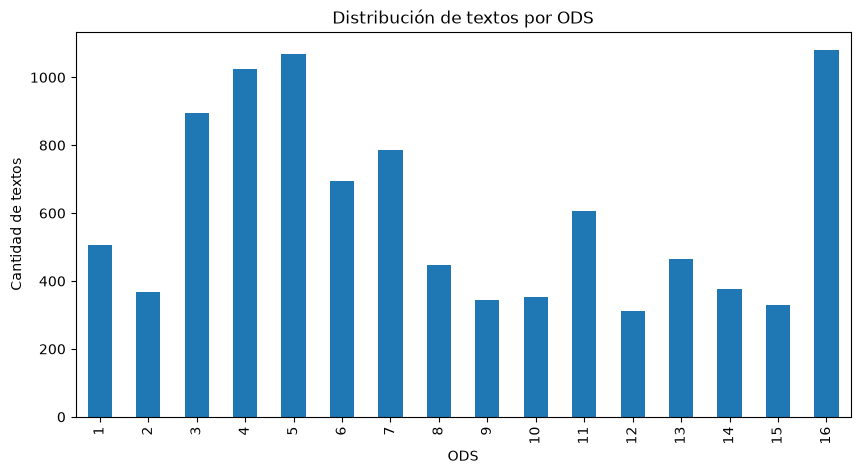

In [4]:
ods_count = df["ODS"].value_counts().sort_index()

ods_count.plot(kind="bar", figsize=(10,5))
plt.title("Distribución de textos por ODS")
plt.xlabel("ODS")
plt.ylabel("Cantidad de textos")
plt.show()

In [5]:
df["textos"].str.split().str.len().describe()

count    9656.000000
mean      111.017295
std        37.082212
min        24.000000
25%        82.000000
50%       105.000000
75%       135.000000
max       268.000000
Name: textos, dtype: float64

**Limpieza de texto**

Se realiza una limpieza basica de texto removiendo posibles signos y numeros de la columna que se usara para crear los vectores.

In [6]:
import re

def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)  # quitar números y signos, conservar tildes/ñ
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df["texto_limpio"] = df["textos"].apply(limpiar_texto) 

df["texto_limpio"].head()

0    aprendizaje y educación se consideran sinónimo...
1    no dejar clara la naturaleza de estos riesgos ...
2    como resultado un mayor y mejorado acceso al a...
3    con el congreso firmemente en control de la ju...
4    luego dos secciones finales analizan las impli...
Name: texto_limpio, dtype: str

**Split de datos**

Se realiza un split del dataset 80/20 y se usa stratify en la columna ODS para que las clases se vean representadas tanto en train como test.

In [7]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["texto_limpio"],
    df["ODS"],
    test_size=0.2,
    random_state=42,
    stratify=df["ODS"] #Mantiene la proporcion de clases para hacer la division de test train
)

print(X_train_text.shape, X_test_text.shape)

(7724,) (1932,)


### 2. Creacion de pipeline

**Vectorizado de datos**

Se implementa un vectorizador TfidfVectorizer con el parametro stopwords = stopwords.words('spanish') para que los conectores no se incluyan ya que no aportan a la distincion de las clases.

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
import nltk

nltk.download('stopwords')

stopwords_es = stopwords.words('spanish')

vectorizador = TfidfVectorizer(stop_words=stopwords_es)

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Modelo SVD**

Se define el modelo TruncatedSVD para la agrupacion por topicos los cuales se usaran para posteriormente clasificar las oraciones

In [9]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(random_state=42)

**Modelo de regresion logistica**

Se define un modelo de regresion logistica para usarse como clasificador, este tomara el texto como entrada y realizara la clasificacion de las oraciones en las clases que encuentre el modelo TruncatedSVD

In [10]:
from sklearn.linear_model import LogisticRegression

logisticRegresion = LogisticRegression(max_iter=1000, random_state=42)

**Definicion de hiperparametros**

Definimos los hiperparametros que se van a optimizar en la busqueda de **GridSearchCV**

- **tfidf__ngram_range** Se pide que compare palabras individuales vs parejas de palabras en el vectorizado del texto
- **tfidf__min_df** Compara los umbrales de frecuencia minima de las palabras o pares que se usan
- **tfidf__max_df** Se establece 0.9 como unico valor para que excluya la palabras con una frecuencia muy alta ya que no aportarian a la distincion de clases
- **tfidf__max_features** Se explora el tamaño del vocabulario que puede ser mas optimo para la posterior clasificacion
- **svd__n_components** Se define un rango para buscar cual cantidad de componentes produce un mejor desempeño para la clasificacion
- **clf__C** Se explora valores para ver que tanto ajuste con respecto a los datos da mejor desempeño

In [11]:
param_grid = {
    'tfidf__ngram_range': [(1, 1), (1, 2)],
    'tfidf__min_df': [3, 5],
    'tfidf__max_df': [0.9],
    'tfidf__max_features': [8000, 10000],
    'svd__n_components': [200, 300, 400],
    'clf__C': [0.1, 1, 10]
}

**Creacion de pipeline**

Se crea el pipeline y se define el GridSearchCV junto a los modelos y parametros definidos anteriormente
- **F1_macro** Se busca optimizar el F1 el cual nos dira cual modelo se desempeña mejor en promedio, evaluando las 17 clases por separado y luego sacando el promedio de estas

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=stopwords_es, sublinear_tf=True)),
    ('svd', TruncatedSVD(random_state=42)),
    ('clf', LogisticRegression(max_iter=500, random_state=42))
])

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)

**Entrenamiento**

In [13]:
grid_search.fit(X_train_text, y_train)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor F1-macro (CV):", grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
[CV] END clf__C=0.1, svd__n_components=200, tfidf__max_df=0.9, tfidf__max_features=8000, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=   2.6s
[CV] END clf__C=0.1, svd__n_components=200, tfidf__max_df=0.9, tfidf__max_features=8000, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=   2.5s
[CV] END clf__C=0.1, svd__n_components=200, tfidf__max_df=0.9, tfidf__max_features=8000, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=   2.4s
[CV] END clf__C=0.1, svd__n_components=200, tfidf__max_df=0.9, tfidf__max_features=8000, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=   2.5s
[CV] END clf__C=0.1, svd__n_components=200, tfidf__max_df=0.9, tfidf__max_features=8000, tfidf__min_df=3, tfidf__ngram_range=(1, 1); total time=   2.0s
[CV] END clf__C=0.1, svd__n_components=200, tfidf__max_df=0.9, tfidf__max_features=8000, tfidf__min_df=3, tfidf__ngram_range=(1, 2); total time=   4.2s
[CV] END clf__C=0.1, svd__

### 3. Analisis de resultados

**Evaluacion**

Se evalua con test el mejor modelo que es el que tiene los siguientes parametros:

```json
{
  "clf__C": 10,
  "svd__n_components": 400,
  "tfidf__max_df": 0.9,
  "tfidf__max_features": 10000,
  "tfidf__min_df": 3,
  "tfidf__ngram_range": [1, 2]
}
```


In [14]:
from sklearn.metrics import f1_score

mejor_pipeline = grid_search.best_estimator_

y_pred = mejor_pipeline.predict(X_test_text)

f1_test = f1_score(y_test, y_pred, average='macro')
print(f"F1-macro en test: {f1_test:.4f}")

F1-macro en test: 0.8410


El modelo con los mejores parametros encontrados nos da un F1-macro de 0.8410 en test, lo cual es muy bueno

In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.86      0.78      0.82       101
           2       0.81      0.85      0.83        74
           3       0.91      0.93      0.92       179
           4       0.94      0.97      0.95       205
           5       0.93      0.94      0.94       214
           6       0.95      0.93      0.94       139
           7       0.85      0.91      0.88       158
           8       0.59      0.58      0.59        89
           9       0.70      0.72      0.71        69
          10       0.66      0.64      0.65        70
          11       0.82      0.80      0.81       122
          12       0.81      0.76      0.78        62
          13       0.85      0.90      0.88        93
          14       0.97      0.85      0.91        75
          15       0.93      0.86      0.90        66
          16       0.95      0.96      0.96       216

    accuracy                           0.87      1932
   macro avg       0.85   

El classification report nos muestra que la clase que se pudo clasificar on un mejor desempeño fue la ODS 16 y la mas baja fue ODS 8

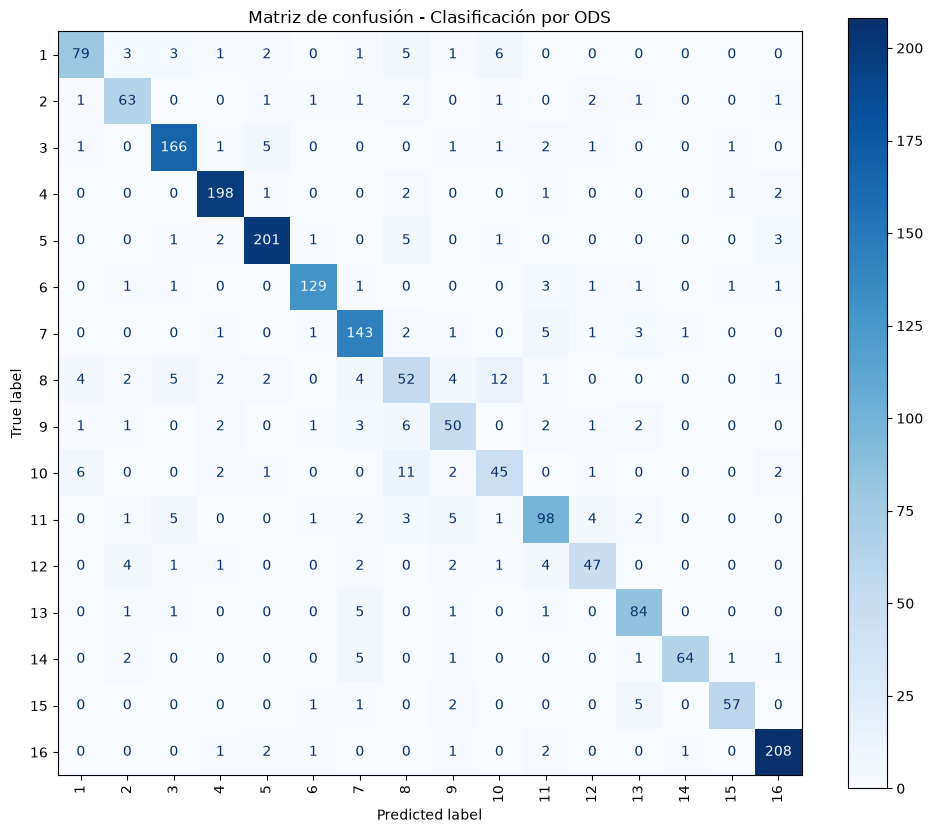

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    cmap='Blues',
    xticks_rotation='vertical',
    ax=ax
)
plt.title('Matriz de confusión - Clasificación por ODS')
plt.show()

Segun la matriz de confusion se puede observar que el modelo tiende a confundir las clases ODS 8 y 10, puede ser por unas tendencias en el texto muy parecidas

In [19]:
indices_ejemplo = X_test_text.index[:4]  

for idx in indices_ejemplo:
    texto = X_test_text.loc[idx]
    real = y_test.loc[idx]
    pred = mejor_pipeline.predict([texto])[0]
    
    print(f"Texto: {texto}")
    print(f"ODS real: {real} | ODS predicho: {pred}")
    print(f"{'✓ Correcto' if real == pred else '✗ Incorrecto'}")

    ejemplo_ods = X_test_text[y_test == pred].iloc[0]
    print(f"\nEjemplo de referencia del ODS {pred} (predicho): {ejemplo_ods}")
    print("-" * 80)

Texto: en la última década muchos de los procesos de paz en el continente africano entre y no tuvieron mujeres como mediadoras principales maximizar los beneficios de la participación de las mujeres en la prevención de conflictos y la consolidación de la paz exige pasar de la inclusión a la asociación para el cambio social la ausencia de las mujeres en los procesos de paz no puede explicarse por su supuesta falta de experiencia en resolución de conflictos o negociaciones
ODS real: 5 | ODS predicho: 5
✓ Correcto

Ejemplo de referencia del ODS 5 (predicho): en la última década muchos de los procesos de paz en el continente africano entre y no tuvieron mujeres como mediadoras principales maximizar los beneficios de la participación de las mujeres en la prevención de conflictos y la consolidación de la paz exige pasar de la inclusión a la asociación para el cambio social la ausencia de las mujeres en los procesos de paz no puede explicarse por su supuesta falta de experiencia en resolución

Se puede observar que en los casos en los que el modelo realiza una clasificacion erronea las dos clases ODS comparten palabras significativas que pueden hacer que el modelo genere confusion:
- En el ejemplo 4 el texto real trataba sobre género/trabajo doméstico pero mencionaba educación, lo cual confunde la clasificacion. 
- En el ejemplo 3 ambos hablan puntualmente de gestión de residuos, lo cual se comparte en otros ODS.